In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class GMM:
    def _init_params(self, X, K): # khởi tạo tham số cho mỗi cluster
        N,D = X.shape

        # chọn ngẫu nhiên K điểm làm mean ban đầu
        indices = np.random.choice(N, K, replace=False)
        mu = X[indices]  # shape (K,D)

        # covariance ban đầu = ma trận đơn vị cho mỗi cluster
        sigma = np.array([np.eye(D)] * K) # shape (K, D, D)

        # mixing coefficient: ban đầu đều nhau
        pi = np.ones(K) / K # shape (K,) - mỗi phần tử = 1/3

        return mu, sigma, pi

    # E-step
    def _gaussian(self, X, mu, sigma):
        N, D = X.shape
        # hệ số chuẩn hóa
        coeff = 1 / ((2 * np.pi) ** (D/2) * np.sqrt(np.linalg.det(sigma)))
        # X - mu: shape (N,D)
        diff = X - mu
        # Tính exp(-0.5 * diff @ sigma_inv @ diff.T) cho từng điểm
        sigma_inv = np.linalg.inv(sigma)
        exponent = -0.5 * np.sum(diff @ sigma_inv * diff, axis=1) # shape (N,)
        return coeff * np.exp(exponent) # shape (N,)

    def _e_step(self, X, mu, sigma, pi, K):
        N = X.shape[0]
        gamma = np.zeros((N,K)) #shape (N,K)

        # Tính tử số: π_k * N(x | μ_k, Σ_k) cho từng k
        for k in range(K):
            gamma[:, k] = pi[k] * self._gaussian(X, mu[k], sigma[k])

        # Chia cho tổng (mẫu số) — normalize theo axis=1
        gamma /= gamma.sum(axis=1, keepdims=True)   # shape (N, K)
        return gamma

    def _m_step(self, X, gamma, K):
        N, D = X.shape
        mu    = np.zeros((K, D))
        sigma = np.zeros((K, D, D))
        pi    = np.zeros(K)

        for k in range(K):
            # N_k = tổng γ_k(x_n) — "số điểm hiệu dụng" của cluster k
            Nk = gamma[:, k].sum()           # scalar

            # Cập nhật mu_k
            mu[k] = (gamma[:, k] @ X) / Nk  # shape (D,)

            # Cập nhật sigma_k
            diff = X - mu[k]                 # shape (N, D)
            sigma[k] = (gamma[:, k] * diff.T) @ diff / Nk  # shape (D, D)

            sigma[k] += 1e-6 * np.eye(D)

            # Cập nhật pi_k
            pi[k] = Nk / N

        return mu, sigma, pi

    def fit(self, X, K, max_iter=100, tol=1e-4):
        mu, sigma, pi = self._init_params(X, K)
        log_likelihoods = []

        for i in range(max_iter):
            # E-step
            gamma = self._e_step(X, mu, sigma, pi, K)

            # M-step
            mu, sigma, pi = self._m_step(X, gamma, K)

            # Tính log-likelihood
            ll = self._log_likelihood(X, mu, sigma, pi, K)
            log_likelihoods.append(ll)

            # Kiểm tra hội tụ
            if i > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
                print(f"Hội tụ sau {i+1} vòng lặp")
                break

        return gamma, mu, sigma, pi, log_likelihoods

    def _log_likelihood(self, X, mu, sigma, pi, K):
        N = X.shape[0]
        ll = 0
        for n in range(N):
            ll += np.log(sum(pi[k] * self._gaussian(X[n:n+1], mu[k], sigma[k])
                            for k in range(K)))
        return ll




### Assignment 1


In [3]:
means = [[2,2], [8,3],[3,6]]
cov = [[1,0], [0,1]]
N = 200

# Mỗi dòng sinh ra array shape (200, 2)
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)

X = np.concatenate((X0, X1, X2), axis = 0)
K = 3

model_gmm = GMM()
gamma, mu, sigma, pi, ll = model_gmm.fit(X,K)

print(f"Mu tìm được:\n{mu}")
print(f"Mu thật:\n{means}")

Mu tìm được:
[[2.75100665 3.94829262]
 [7.8486506  2.91950244]
 [2.17276007 3.92158283]]
Mu thật:
[[2, 2], [8, 3], [3, 6]]


### Assignment 2

Hội tụ sau 32 vòng lặp


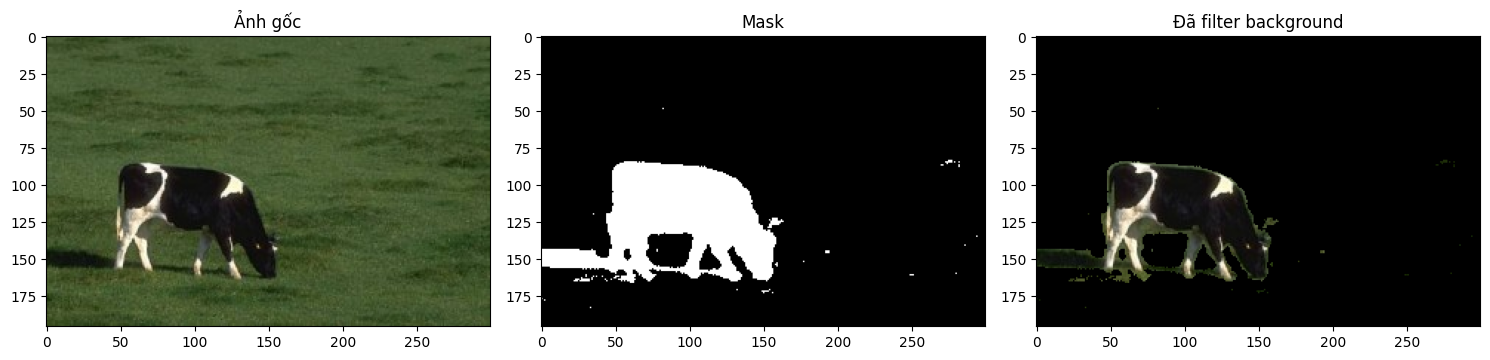

In [7]:
from PIL import Image

gmm = GMM()

image = Image.open('cow.jpg').convert("RGB")
image = np.array(image)
X = image.reshape(-1,3).astype(np.float64)

X = X / 255.0

# Chạy GMM với 2 cluster: background (xanh lá) và foreground (con bò)
gamma, mu, sigma, pi, ll = gmm.fit(X, K=2)

# Gán nhãn: mỗi pixel thuộc cluster có gamma cao hơn
labels = np.argmax(gamma, axis=1)  # shape (H*W,)

# Reshape labels về kích thước ảnh gốc
H, W, _ = image.shape
labels = labels.reshape(H, W)      # shape (H, W)

# Xác định cluster nào là background (xanh lá)
# Cluster nào có mean G cao nhất → là background
bg_cluster = np.argmax(mu[:, 1])   # kênh G = index 1 trong RGB

# Tạo mask: background = 0, foreground = 255
mask = (labels != bg_cluster).astype(np.uint8) * 255  # shape (H, W)

# Áp mask vào ảnh gốc
result = image.copy()
result[labels == bg_cluster] = [0, 0, 0]  # tô đen background

# Hiển thị kết quả
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title("Ảnh gốc")
axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Mask")
axes[2].imshow(result)
axes[2].set_title("Đã filter background")
plt.tight_layout()
plt.show()
